In [4]:
import numpy as np 
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from sympy.physics.quantum.dagger import Dagger
import math
import random
import cmath
from sympy import I, Matrix, symbols
from sympy.physics.quantum import TensorProduct
import pandas as pd
from IPython.display import clear_output
import Hamiltonian
import build_H
import numpy as np
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import eigsh

In [122]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#device = 'cpu'
number_of_qubits = 18
from itertools import product

basis = torch.zeros(2**number_of_qubits,number_of_qubits)
r = 2**number_of_qubits - 1
#r = 0
for p in product('10', repeat= number_of_qubits):
    for i in range(number_of_qubits):
        #print(p[i])
        #if(float(p[i]) == 0):
        #    basis[r][i] = -1
        #else:
        basis[r][i] = float(p[i])
    r -= 1
print(basis)


sum_spin = math.ceil((number_of_qubits - 1) / 2 )
print(sum_spin)
good_vectors = basis.sum(dim = 1)
good_vectors = (good_vectors == sum_spin).nonzero()[:,0]
#print(good_vectors)
sub_batch = torch.zeros(good_vectors.shape[0], number_of_qubits)
i = torch.arange(0, good_vectors.shape[0], 1)
print(i.shape, good_vectors.shape)
sub_batch[i, :] = basis[good_vectors, :]
good_batch = sub_batch




tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 1.],
        [0., 0., 0.,  ..., 0., 1., 0.],
        ...,
        [1., 1., 1.,  ..., 1., 0., 1.],
        [1., 1., 1.,  ..., 1., 1., 0.],
        [1., 1., 1.,  ..., 1., 1., 1.]])
9
torch.Size([48620]) torch.Size([48620])


torch.Size([1024])


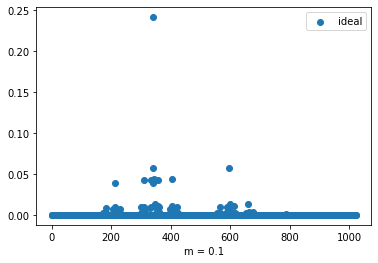

In [6]:
import matplotlib.colors as mcolors
eigenvectors = torch.tensor(np.load('number_of_qubits_10.npy')).float()

my_way = torch.zeros(2**10, dtype = torch.double)
print(eigenvectors.shape)
x = torch.arange(2**10)
my_way = eigenvectors
fig, ax = plt.subplots()
ax.scatter(x, eigenvectors**2, alpha = 1, label='ideal')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()

torch.Size([512])


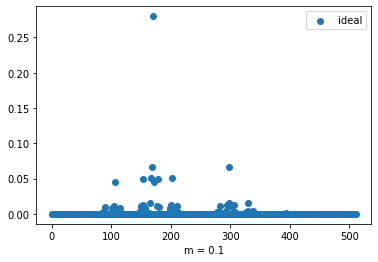

In [84]:
import matplotlib.colors as mcolors
eigenvectors = torch.tensor(np.load('number_of_qubits_9.npy')).float()

my_way9 = torch.zeros(2**10, dtype = torch.double)
print(eigenvectors.shape)
x = torch.arange(2**9)
my_way9 = eigenvectors
fig, ax = plt.subplots()
ax.scatter(x, eigenvectors**2, alpha = 1, label='ideal')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()

torch.Size([4096])


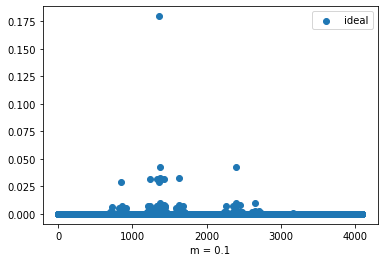

In [7]:
import matplotlib.colors as mcolors
eigenvectors = torch.tensor(np.load('number_of_qubits_12.npy')).float()

my_way_12 = torch.zeros(2**12, dtype = torch.double)
print(eigenvectors.shape)
x = torch.arange(2**12)
my_way_12 = eigenvectors
fig, ax = plt.subplots()
ax.scatter(x, my_way_12**2, alpha = 1, label='ideal')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()

torch.Size([1024])
tensor(0.8466)
tensor(1.0000)


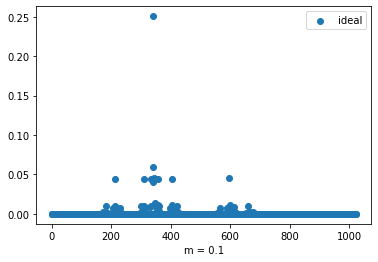

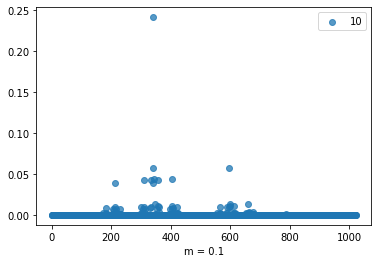

tensor([[341],
        [342],
        [597]])
tensor(0.9986)


In [41]:
r = my_way_12[1024:1024 + 1024]
print(r.shape)
print(r.norm())
print(my_way.norm())
#r = r/r.norm()
x = torch.arange(r.shape[0])

r = r/r.norm()

fig, ax = plt.subplots()
ax.scatter(x, r**2, alpha = 1, label='ideal')
#ax.scatter(x, my_way**2, alpha = 0.75, label='10')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()

fig, ax = plt.subplots()
#ax.scatter(x, r**2, alpha = 1, label='ideal')
ax.scatter(x, my_way**2, alpha = 0.75, label='10')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()
print((my_way**2 > 0.05).nonzero())
print(r.dot(my_way))

tensor(0.1400)
tensor(0.1776)


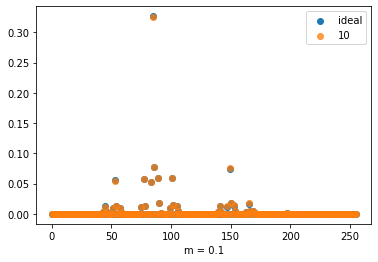

tensor(1.0000)


In [42]:
rr = r[512:512+256]
my = my_way[512:512+256]
print(rr.norm()**2)
print(my.norm()**2)
rr = rr/rr.norm()
my = my/my.norm()
fig, ax = plt.subplots()
x = torch.arange(0,256)
#r = r/r.norm()
ax.scatter(x, rr**2, alpha = 1, label='ideal')
ax.scatter(x, my**2, alpha = 0.75, label='10')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()
print(rr.dot(my))

tensor(0.8614)
tensor(0.8466)


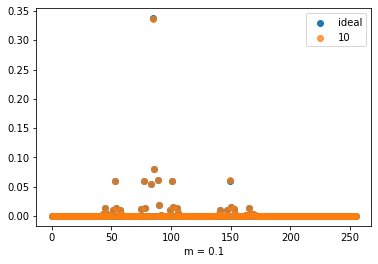

tensor(1.0000)


In [62]:
rr = r[256:512]
my = my_way[256:512]
print(rr.norm())
print(my.norm())
rr = rr/rr.norm()
my = my/my.norm()

fig, ax = plt.subplots()
x = torch.arange(0,256)
#r = r/r.norm()
ax.scatter(x, rr**2, alpha = 1, label='ideal')
ax.scatter(x, my**2, alpha = 0.75, label='10')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()

print(rr.dot(my))

tensor(0.3422)
tensor(0.3230)


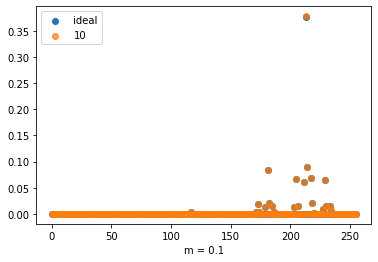

tensor(1.0000)


In [58]:
rr = r[0:256]
my = my_way[0:256]
print(rr.norm())
print(my.norm())
rr = rr/rr.norm()
my = my/my.norm()

fig, ax = plt.subplots()
x = torch.arange(0,256)
#r = r/r.norm()
ax.scatter(x, rr**2, alpha = 1, label='ideal')
ax.scatter(x, my**2, alpha = 0.75, label='10')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()

print(rr.dot(my))

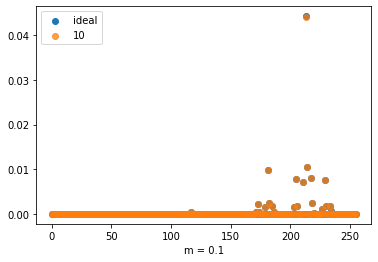

In [65]:
a = my_way[0:256]
rr = r[0:256]

a = a*0.3422/0.3230
#a = a/a.norm()
fig, ax = plt.subplots()
x = torch.arange(0,256)
#r = r/r.norm()
ax.scatter(x, a**2, alpha = 1, label='ideal')
ax.scatter(x, rr**2, alpha = 0.75, label='10')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()


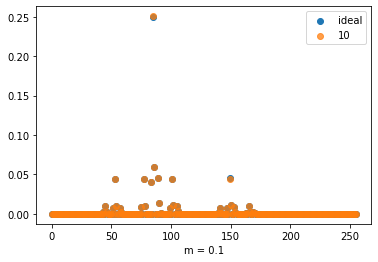

In [64]:
b = my_way[256:512]
rr = r[256:512]

b = b*0.8614/0.8466
#a = a/a.norm()
fig, ax = plt.subplots()
x = torch.arange(0,256)
#r = r/r.norm()
ax.scatter(x, b**2, alpha = 1, label='ideal')
ax.scatter(x, rr**2, alpha = 0.75, label='10')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()

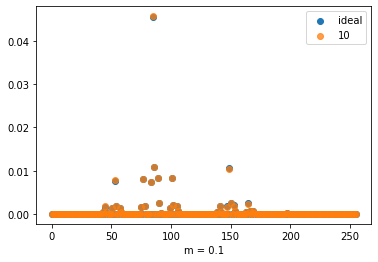

In [66]:
c = my_way[512:512 + 256]
rr = r[512:512+256]

c = c*0.3741/0.4214
#a = a/a.norm()
fig, ax = plt.subplots()
x = torch.arange(0,256)
#r = r/r.norm()
ax.scatter(x, c**2, alpha = 1, label='ideal')
ax.scatter(x, rr**2, alpha = 0.75, label='10')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()

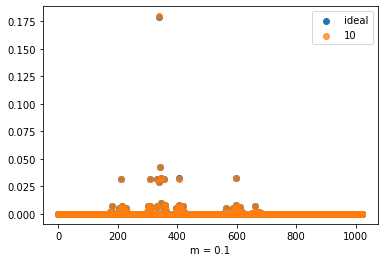

tensor(0.7161)


In [94]:
center = torch.zeros(1024)
i = torch.arange(256)
center[i] = a[i]
center[i + 256] = b[i]
center[i+512] = c[i]
r = my_way_12[1024:1024 + 1024]

center *= 0.8466
#r = r/r.norm()
fig, ax = plt.subplots()
x = torch.arange(1024)
ax.scatter(x, center**2, alpha = 1, label='ideal')
ax.scatter(x, r**2 ,alpha = 0.75, label='10')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()
print(center.dot(r))

tensor(0.4213)


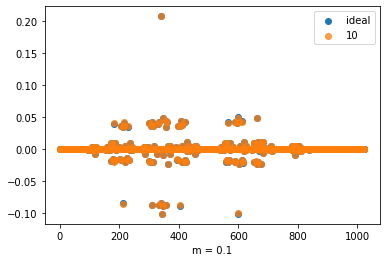

tensor(0.1775)


In [95]:
right = -my_way*0.4213
r = my_way_12[2048:2048 + 1024]
print(r.norm())

fig, ax = plt.subplots()
x = torch.arange(1024)
ax.scatter(x, right, alpha = 1, label='ideal')
ax.scatter(x, r ,alpha = 0.75, label='10')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()
print(right.dot(r))

tensor(0.3221)


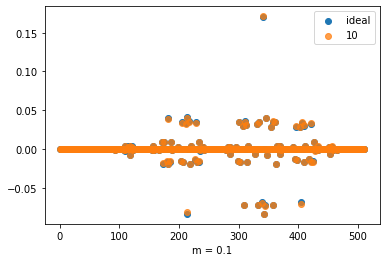

tensor(0.1037)


In [96]:
r = my_way_12[512:1024]
print(r.norm())
left = torch.zeros(512)
i = torch.arange(512)
left[i] = my_way9[511-i] * 0.3221
fig, ax = plt.subplots()
x = torch.arange(512)
ax.scatter(x, left, alpha = 1, label='ideal')
ax.scatter(x, r ,alpha = 0.75, label='10')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()


print(left.dot(r))

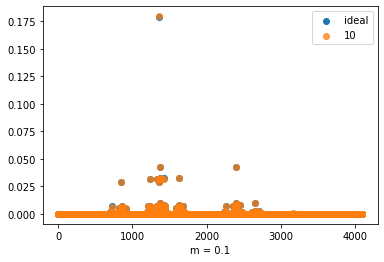

tensor(0.9973)


In [100]:
full = torch.zeros(2**12)
i = torch.arange(512)
j = torch.arange(1024)
full[i + 512] = left[i]
full[1024 + j] = center[j]
full[2048 + j] = right[j] 

fig, ax = plt.subplots()
x = torch.arange(2**12)
ax.scatter(x, full**2, alpha = 1, label='ideal')
ax.scatter(x, my_way_12**2 ,alpha = 0.75, label='10')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()
print(full.dot(my_way_12))

In [ ]:
##################NORM########################################3

16384
torch.Size([16384, 1])


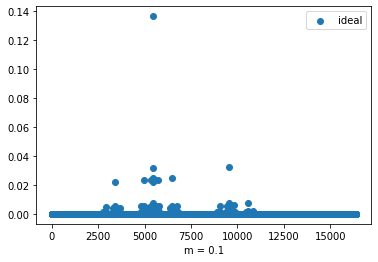

tensor(0.4185) right
tensor(0.8479) center
tensor(0.3224) left


In [125]:
import matplotlib.colors as mcolors
eigenvectors = torch.tensor(np.load('number_of_qubits_14.npy')).float()
print(2**14)
print(eigenvectors.shape)
x = torch.arange(2**14)
my_way14 = eigenvectors
fig, ax = plt.subplots()
ax.scatter(x, eigenvectors**2, alpha = 1, label='ideal')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()

r = my_way14[2**13 : 2**13+2**12]
print(r.norm(), 'right')
r = my_way14[2**13 - 2**12 : 2**13]
print(r.norm(), 'center')
r = my_way14[2**13 - 2**12 - 2**11:2**13 - 2**12]
print(r.norm(), 'left')

65536
torch.Size([12870, 1])


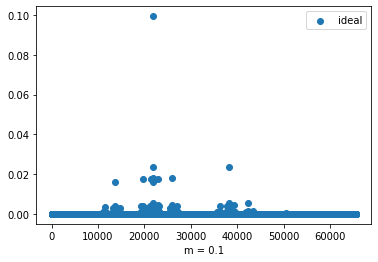

tensor(0.4213) right
tensor(0.8466) center
tensor(0.3222) left


In [121]:
import matplotlib.colors as mcolors
eigenvectors = torch.tensor(np.load('number_of_qubits_16 (2).npy')).float()
print(2**16)
print(eigenvectors.shape)
i = torch.arange(eigenvectors.shape[0])
my_way16 = torch.zeros(2**16)
x = torch.arange(2**16)
my_way16[good_vectors] = eigenvectors[i,0]
fig, ax = plt.subplots()
ax.scatter(x, my_way16**2, alpha = 1, label='ideal')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()
r = my_way16[2**15 : 2**15 + 2**14]
print(r.norm(), 'right')
r = my_way16[2**15 - 2**14 : 2**15]
print(r.norm(), 'center')
r = my_way16[2**15 - 2**14 - 2**13:2**15 - 2**14]
print(r.norm(), 'left')

262144
torch.Size([48620, 1])


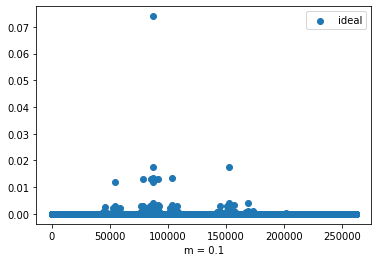

tensor(0.4213) right
tensor(0.8466) center
tensor(0.3222) left


In [124]:
import matplotlib.colors as mcolors
eigenvectors = torch.tensor(np.load('number_of_qubits_18 (1).npy')).float()
print(2**18)
print(eigenvectors.shape)
i = torch.arange(eigenvectors.shape[0])
my_way18 = torch.zeros(2**18)
x = torch.arange(2**18)
my_way18[good_vectors] = eigenvectors[i,0]
fig, ax = plt.subplots()
ax.scatter(x, my_way18**2, alpha = 1, label='ideal')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()
r = my_way18[2**17 : 2**17 + 2**16]
print(r.norm(), 'right')
r = my_way18[2**17 - 2**16 : 2**17]
print(r.norm(), 'center')
r = my_way18[2**17 - 2**16 - 2**15:2**17 - 2**16]
print(r.norm(), 'left')

tensor(0.4185)
tensor(0.9997)


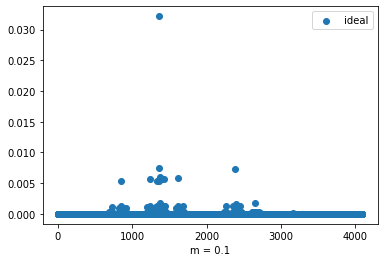

In [107]:
r = my_way14[2**13:2**13+2**12]
print(r.norm())
#r = r/r.norm()

x = torch.arange(r.shape[0])
fig, ax = plt.subplots()
ax.scatter(x, r**2, alpha = 1, label='ideal')
#ax.scatter(x, my, alpha = 0.5, label='10')
ax.set_xlabel('m = 0.1')
ax.legend()
r = r/r.norm()
print(r.view(-1).dot(my_way_12))

torch.Size([306])
tensor(0.7306)


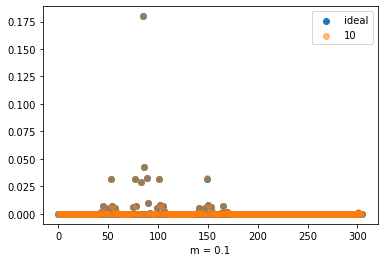

tensor(0.5350)
tensor([[ 53],
        [ 85],
        [101],
        [141],
        [147],
        [149],
        [150],
        [153],
        [165],
        [301]])
tensor(0.0424) tensor(0.0418)


In [ ]:
r = my_way_12[1024 + 256:1024 + 562]
print(r.shape)
print(r.norm())
#r = r/r.norm()
x = torch.arange(r.shape[0])
fig, ax = plt.subplots()
my = my_way[256:562] * 0.863
ax.scatter(x, r**2, alpha = 1, label='ideal')
ax.scatter(x, my**2, alpha = 0.5, label='10')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()
#r = r/r.norm()
#my = my/my.norm()
print(r.view(-1).dot(my.view(-1)))
print(((r**2 - my**2).abs() > 0.0001).nonzero())
print(my[166], r[166])

torch.Size([1024])
tensor(0.4213)


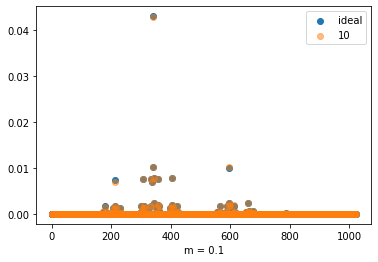

tensor(-1.0000)


In [ ]:
r = my_way_12[2048:3072]
print(r.shape)
print(r.norm())
#r = r/r.norm()
x = torch.arange(r.shape[0])
fig, ax = plt.subplots()
my = my_way * 0.4213
ax.scatter(x, r**2, alpha = 1, label='ideal')
ax.scatter(x, my**2, alpha = 0.5, label='10')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()
r = r/r.norm()
my = my/my.norm()
print(r.view(-1).dot(my.view(-1)))

torch.Size([256])


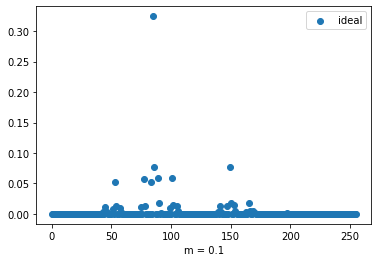

In [ ]:
import matplotlib.colors as mcolors
eigenvectors = torch.tensor(np.load('number_of_qubits_8.npy')).float()

my_way_8 = torch.zeros(2**8, dtype = torch.double)
print(eigenvectors.shape)
x = torch.arange(2**8)
my_way_8 = eigenvectors
fig, ax = plt.subplots()
ax.scatter(x, my_way_8**2, alpha = 1, label='ideal')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()

In [ ]:
def CP_conj(batch):
    add = torch.clone(batch)
    CP_batch = torch.clone(batch)
    i = torch.arange(0,number_of_qubits/2,1).type(torch.LongTensor)
    j = torch.arange(number_of_qubits-1, number_of_qubits/2-1, -1).type(torch.LongTensor)
    CP_batch[:,i] = CP_batch[:,j]
    CP_batch[:,j] = add[:,i]
    add = torch.clone(CP_batch)

    CP_batch[add == 0] = 1
    CP_batch[add == 1] = 0
    return CP_batch

In [ ]:
number_of_qubits = 12
from itertools import product

basis = torch.zeros(2**number_of_qubits,number_of_qubits)
r = 2**number_of_qubits - 1
#r = 0
for p in product('10', repeat= number_of_qubits):
    for i in range(number_of_qubits):
        #print(p[i])
        #if(float(p[i]) == 0):
        #    basis[r][i] = -1
        #else:
        basis[r][i] = float(p[i])
    r -= 1
print(basis)


sum_spin = math.ceil((number_of_qubits - 1) / 2 )
print(sum_spin)
good_vectors = basis.sum(dim = 1)
good_vectors = (good_vectors == sum_spin).nonzero()[:,0]
#print(good_vectors)
sub_batch = torch.zeros(good_vectors.shape[0], number_of_qubits)
i = torch.arange(0, good_vectors.shape[0], 1)
print(i.shape, good_vectors.shape)
sub_batch[i, :] = basis[good_vectors, :]
good_batch = sub_batch



tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 1.],
        [0., 0., 0.,  ..., 0., 1., 0.],
        ...,
        [1., 1., 1.,  ..., 1., 0., 1.],
        [1., 1., 1.,  ..., 1., 1., 0.],
        [1., 1., 1.,  ..., 1., 1., 1.]])
6
torch.Size([924]) torch.Size([924])


tensor(0.8481) tensor(0.9470)


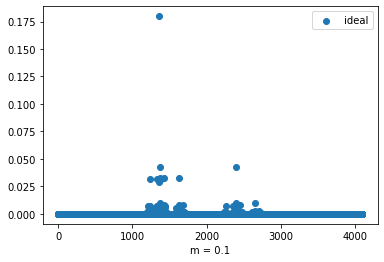

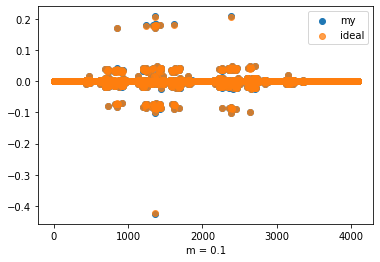

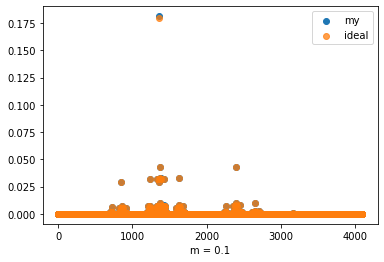

tensor(0.9943)


In [ ]:

# R = my_way.reshape(-1)
# RR= my_way_8.reshape(-1)
# distr = torch.zeros(2**number_of_qubits)
# ind = torch.arange(2**(number_of_qubits - 2))
# ind1 = torch.arange(2**(number_of_qubits - 3))
# ind2 = torch.arange(2**(number_of_qubits - 4))
# distr[ind1 + 2**(number_of_qubits - 2)] = R[ind1]*0.88
# distr[ind2 + 2**(number_of_qubits - 2) + 2**(number_of_qubits - 3)] = RR[ind2]*0.56
# distr[ind + 2**(number_of_qubits - 1)] = -R[ind]*0.65
# r = distr[1024:2048]
# print(r.norm(), distr.norm())

R = my_way.reshape(-1)
#RR= my_way_8.reshape(-1)
distr = torch.zeros(2**number_of_qubits)
ind = torch.arange(2**(number_of_qubits - 2))
#ind1 = torch.arange(2**(number_of_qubits - 3))
ind2 = torch.arange(2**(number_of_qubits - 4))
distr[ind2 + 2**(number_of_qubits - 2)] = R[ind2]*0.896

distr[ind2 + 2**(number_of_qubits - 2) + 2**(number_of_qubits - 4)] = R[ind2 +  2**(number_of_qubits - 4)]*0.863

distr[ind2 + 2**(number_of_qubits - 2) + 2**(number_of_qubits - 3)] = R[ind2 +  2**(number_of_qubits - 3)]*0.757

distr[ind + 2**(number_of_qubits - 1)] = -R[ind]*0.4213
r = distr[1024:2048]
print(r.norm(), distr.norm())

fig, ax = plt.subplots()
x = torch.arange(2**number_of_qubits)
ax.scatter(x, distr**2, alpha = 1, label='ideal')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()

ind = (torch.abs(distr) > 0.001).nonzero()
batch = basis[ind].view(-1, number_of_qubits)

CP_batch = CP_conj(batch)
#number_of_qubits = 16
a = 2**torch.arange(number_of_qubits -1, -1,-1)
CP_ind = CP_batch*a 
CP_ind = (CP_ind.sum(dim = 1)).view(CP_ind.shape[0], 1)

#print(((basis[CP_ind.reshape(-1).numpy()].sum(1))), 'good')
distr[CP_ind.numpy()] = distr[ind]
distr = distr/distr.norm()
fig, ax = plt.subplots()

x = torch.arange(2**number_of_qubits)
ax.scatter(x, distr, alpha = 1, label='my')
ax.scatter(x, my_way_12, alpha = 0.75, label='ideal')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()

fig, ax = plt.subplots()

#x = torch.arange(2**8 - 64-128)
ax.scatter(x, distr**2, alpha = 1, label='my')
ax.scatter(x, my_way_12**2, alpha = 0.75, label='ideal')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()
print(my_way_12.view(-1).dot(distr))


In [ ]:
print(my_way_12[1365]**2)
print(distr[1365]**2)

tensor(0.1796)
tensor(0.1771)


torch.Size([4096])


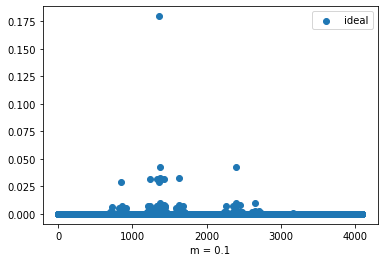

In [ ]:
import matplotlib.colors as mcolors
eigenvectors = torch.tensor(np.load('number_of_qubits_12.npy')).float()

my_way = torch.zeros(2**12, dtype = torch.double)
print(eigenvectors.shape)
x = torch.arange(2**12)
my_way = eigenvectors
fig, ax = plt.subplots()
ax.scatter(x, eigenvectors**2, alpha = 1, label='ideal')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()

In [ ]:
number_of_qubits = 14
from itertools import product

basis = torch.zeros(2**number_of_qubits,number_of_qubits)
r = 2**number_of_qubits - 1
#r = 0
for p in product('10', repeat= number_of_qubits):
    for i in range(number_of_qubits):
        #print(p[i])
        #if(float(p[i]) == 0):
        #    basis[r][i] = -1
        #else:
        basis[r][i] = float(p[i])
    r -= 1
print(basis)


sum_spin = math.ceil((number_of_qubits - 1) / 2 )
print(sum_spin)
good_vectors = basis.sum(dim = 1)
good_vectors = (good_vectors == sum_spin).nonzero()[:,0]
#print(good_vectors)
sub_batch = torch.zeros(good_vectors.shape[0], number_of_qubits)
i = torch.arange(0, good_vectors.shape[0], 1)
print(i.shape, good_vectors.shape)
sub_batch[i, :] = basis[good_vectors, :]
good_batch = sub_batch



tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 1.],
        [0., 0., 0.,  ..., 0., 1., 0.],
        ...,
        [1., 1., 1.,  ..., 1., 0., 1.],
        [1., 1., 1.,  ..., 1., 1., 0.],
        [1., 1., 1.,  ..., 1., 1., 1.]])
7
torch.Size([3432]) torch.Size([3432])


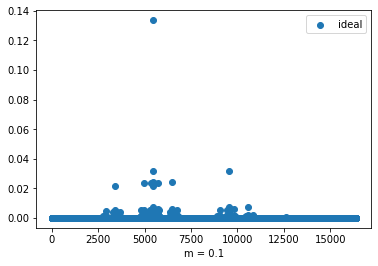

In [ ]:
import matplotlib.colors as mcolors
eigenvectors = torch.tensor(np.load('number_of_qubits_14 (2).npy')).float()

my_way_14 = torch.zeros(2**14, 1)
i = torch.arange(math.ceil(good_vectors.shape[0]))
my_way_14[good_vectors, :] = eigenvectors[i, :]
x = torch.arange(2**14)
fig, ax = plt.subplots()
ax.scatter(x, my_way_14**2, alpha = 1, label='ideal')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()

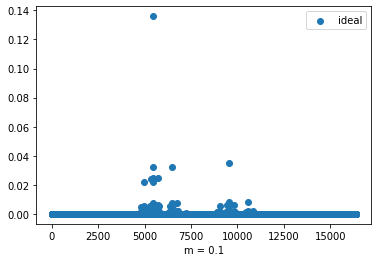

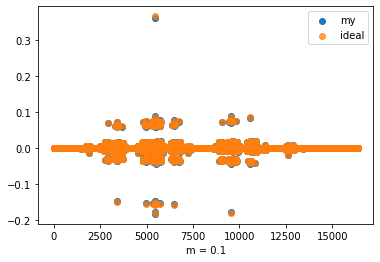

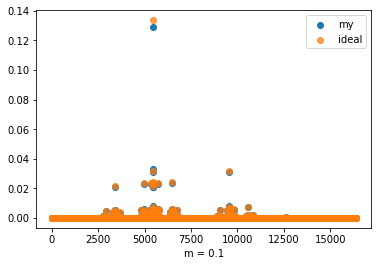

tensor(0.9932)


In [ ]:

R = my_way.reshape(-1)

distr = torch.zeros(2**number_of_qubits)
ind = torch.arange(2**(number_of_qubits - 2))
distr[ind + 2**(number_of_qubits - 2)] = -R[ind]*0.87
distr[ind + 2**(number_of_qubits - 1)] = R[ind]*0.44

fig, ax = plt.subplots()
x = torch.arange(2**number_of_qubits)
ax.scatter(x, distr**2, alpha = 1, label='ideal')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()

ind = (torch.abs(distr) > 0.001).nonzero()
batch = basis[ind].view(-1, number_of_qubits)

CP_batch = CP_conj(batch)
#number_of_qubits = 16
a = 2**torch.arange(number_of_qubits -1, -1,-1)
CP_ind = CP_batch*a 
CP_ind = (CP_ind.sum(dim = 1)).view(CP_ind.shape[0], 1)

#print(((basis[CP_ind.reshape(-1).numpy()].sum(1))), 'good')
distr[CP_ind.numpy()] = distr[ind]
distr = distr/distr.norm()
fig, ax = plt.subplots()

x = torch.arange(2**number_of_qubits)
ax.scatter(x, distr, alpha = 1, label='my')
ax.scatter(x, my_way_14, alpha = 0.75, label='ideal')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()

fig, ax = plt.subplots()

#x = torch.arange(2**16)
ax.scatter(x, distr**2, alpha = 1, label='my')
ax.scatter(x, my_way_14**2, alpha = 0.75, label='ideal')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()
print(my_way_14.view(-1).dot(distr))


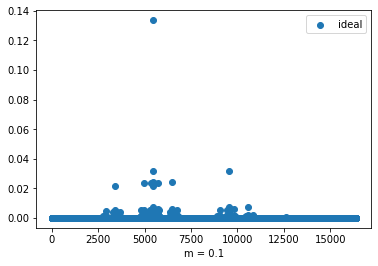

In [ ]:
import matplotlib.colors as mcolors
eigenvectors = torch.tensor(np.load('number_of_qubits_14 (2).npy')).float()

my_way = torch.zeros(2**14, 1)
i = torch.arange(math.ceil(good_vectors.shape[0]))
my_way[good_vectors, :] = eigenvectors[i, :]
fig, ax = plt.subplots()
ax.scatter(x, my_way**2, alpha = 1, label='ideal')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()

In [ ]:
number_of_qubits = 10
from itertools import product

basis = torch.zeros(2**number_of_qubits,number_of_qubits)
r = 2**number_of_qubits - 1
#r = 0
for p in product('10', repeat= number_of_qubits):
    for i in range(number_of_qubits):
        #print(p[i])
        #if(float(p[i]) == 0):
        #    basis[r][i] = -1
        #else:
        basis[r][i] = float(p[i])
    r -= 1
print(basis)


sum_spin = math.ceil((number_of_qubits - 1) / 2 )
print(sum_spin)
good_vectors = basis.sum(dim = 1)
good_vectors = (good_vectors == sum_spin).nonzero()[:,0]
#print(good_vectors)
sub_batch = torch.zeros(good_vectors.shape[0], number_of_qubits)
i = torch.arange(0, good_vectors.shape[0], 1)
print(i.shape, good_vectors.shape)
sub_batch[i, :] = basis[good_vectors, :]
good_batch = sub_batch



tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 1.],
        [0., 0., 0.,  ..., 0., 1., 0.],
        ...,
        [1., 1., 1.,  ..., 1., 0., 1.],
        [1., 1., 1.,  ..., 1., 1., 0.],
        [1., 1., 1.,  ..., 1., 1., 1.]])
5
torch.Size([252]) torch.Size([252])


torch.Size([65536, 1])


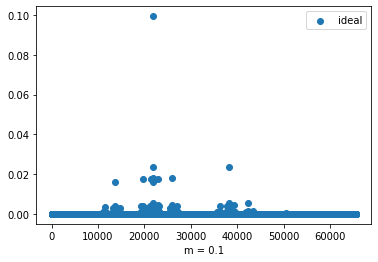

In [ ]:
import matplotlib.colors as mcolors
eigenvectors = torch.tensor(np.load('number_of_qubits_16 (2).npy')).float()

my_way_16 = torch.zeros(2**16, dtype = torch.double)

my_way_16 = torch.zeros(2**16, 1)
i = torch.arange(math.ceil(good_vectors.shape[0]))
my_way_16[good_vectors, 0] = eigenvectors[i, 0]

print(my_way_16.shape)
x = torch.arange(2**16)
fig, ax = plt.subplots()
ax.scatter(x, my_way_16**2, alpha = 1, label='ideal')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()

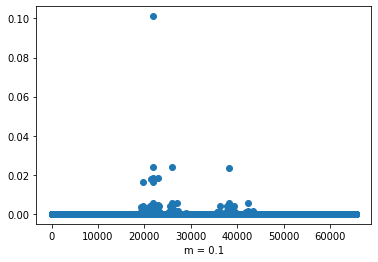

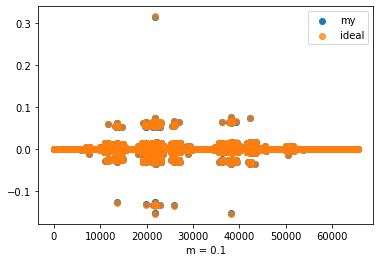

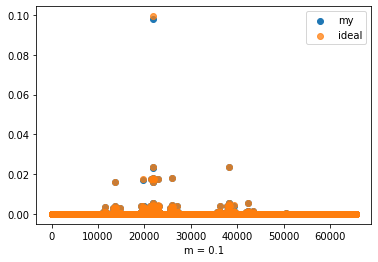

tensor(0.9931)


In [ ]:
R = my_way.reshape(-1)

distr = torch.zeros(2**number_of_qubits)
ind = torch.arange(2**(number_of_qubits - 2))
distr[ind + 2**(number_of_qubits - 2)] = R[ind]*0.87
distr[ind + 2**(number_of_qubits - 1)] = -R[ind]*0.42

fig, ax = plt.subplots()
x = torch.arange(2**number_of_qubits)
ax.scatter(x, distr**2, alpha = 1, label='ideal')
ax.set_xlabel('m = 0.1')
plt.show()

ind = (torch.abs(distr) > 0.001).nonzero()

batch = basis[ind].view(-1, number_of_qubits)
CP_batch = CP_conj(batch)
a = 2**torch.arange(number_of_qubits -1, -1,-1)
CP_ind = CP_batch*a 
CP_ind = (CP_ind.sum(dim = 1)).view(CP_ind.shape[0], 1)

distr[CP_ind.numpy()] = distr[ind]
distr = distr/distr.norm()

fig, ax = plt.subplots()
x = torch.arange(2**number_of_qubits)
ax.scatter(x, distr, alpha = 1, label='my')
ax.scatter(x, my_way_16, alpha = 0.75, label='ideal')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()

fig, ax = plt.subplots()
ax.scatter(x, distr**2, alpha = 1, label='my')
ax.scatter(x, my_way_16**2, alpha = 0.75, label='ideal')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()
print(my_way_16.view(-1).dot(distr))


torch.Size([1024])


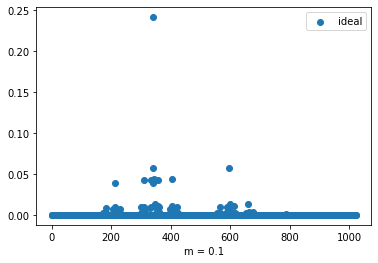

In [ ]:
import matplotlib.colors as mcolors
eigenvectors = torch.tensor(np.load('number_of_qubits_10.npy')).float()

my_way = torch.zeros(2**10, dtype = torch.double)
print(eigenvectors.shape)
x = torch.arange(2**10)
my_way = eigenvectors
fig, ax = plt.subplots()
ax.scatter(x, eigenvectors**2, alpha = 1, label='ideal')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()

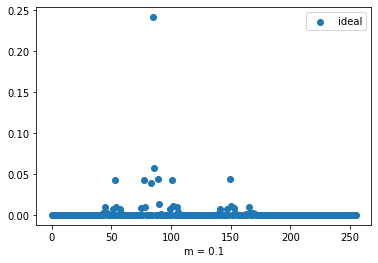

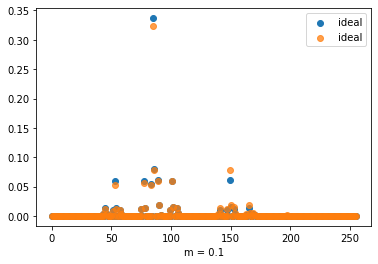

In [ ]:
r = my_way[256:256+256]
x = torch.arange(2**8)
fig, ax = plt.subplots()
ax.scatter(x, r**2, alpha = 1, label='ideal')

ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()
r = r/r.norm()
fig, ax = plt.subplots()
ax.scatter(x, r**2, alpha = 1, label='ideal')
ax.scatter(x, my_way8**2, alpha = 0.75, label='ideal')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()


torch.Size([64])


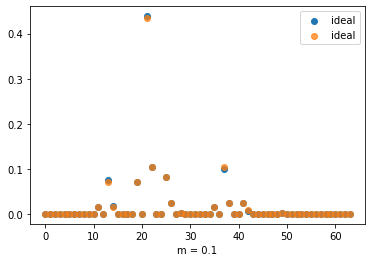

In [ ]:
t = r[128: 128 + 64]
t = t/t.norm()
x = torch.arange(2**6)
print(t.shape)
fig, ax = plt.subplots()
ax.scatter(x, t**2, alpha = 1, label='ideal')
ax.scatter(x, my_way6**2, alpha = 0.75, label='ideal')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()


torch.Size([256])
tensor(0.8616) tensor(0.8467)
1.0


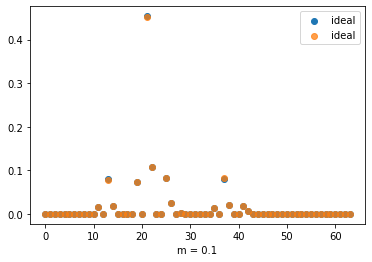

tensor(-1.0000)
tensor([[317.],
        [221.],
        [349.],
        [605.],
        [413.],
        [365.]])
tensor([])


IndexError: ignored

In [ ]:
r = r[64:128]
k = my_way8[64:128]
print(my_way8.shape)
print(r.norm(), k.norm())
r = r/r.norm()
k = k/k.norm()
print(k.shape[0]/ r.shape[0])
x = torch.arange(k.shape[0])

fig, ax = plt.subplots()
ax.scatter(x, r**2, alpha = 1, label='ideal')
ax.scatter(x, k**2, alpha = 0.75, label='ideal')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()

print(r.dot(k))
 
t = torch.zeros(2**10)
a = 2**torch.arange(number_of_qubits -1, -1,-1)
CP_ind = cp*a 
CP_ind = (CP_ind.sum(dim = 1)).view(CP_ind.shape[0], 1)
print(CP_ind)
CP_ind = torch.tensor([333.,309.,213., 341.,405., 357., 345.])
p = torch.tensor([])
print(p)
r[CP_ind - 256] = r[p-256]

fig, ax = plt.subplots()
ax.scatter(x, r**2, alpha = 1, label='ideal')
ax.scatter(x, my_way8**2, alpha = 0.75, label='ideal')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()


In [ ]:
basis[165 + 512]

tensor([1., 0., 1., 0., 1., 0., 0., 1., 0., 1.])

In [ ]:
p = (my_way.abs() > 0.024).nonzero().reshape(-1)

In [ ]:
 z = (my_way**2 > 0.006).nonzero().reshape(-1)
 print(z)
 print(basis[z[100:]])
 print(basis[661])


tensor([181, 205, 211, 213, 214, 217, 229, 301, 307, 309, 310, 313, 331, 333,
        334, 339, 341, 342, 345, 346, 355, 357, 358, 361, 397, 403, 405, 406,
        409, 421, 565, 589, 595, 597, 598, 601, 613, 661])
tensor([], size=(0, 10))
tensor([1., 0., 1., 0., 0., 1., 0., 1., 0., 1.])


In [ ]:
print(basis[p])
CP = CP_conj(basis[p])
print(CP)

tensor([[0., 0., 1., 0., 1., 0., 1., 1., 0., 1.],
        [0., 0., 1., 0., 1., 1., 0., 0., 1., 1.],
        [0., 0., 1., 0., 1., 1., 0., 1., 0., 1.],
        [0., 0., 1., 0., 1., 1., 0., 1., 1., 0.],
        [0., 0., 1., 0., 1., 1., 1., 0., 0., 1.],
        [0., 0., 1., 1., 0., 0., 1., 0., 1., 1.],
        [0., 0., 1., 1., 0., 0., 1., 1., 0., 1.],
        [0., 0., 1., 1., 0., 0., 1., 1., 1., 0.],
        [0., 0., 1., 1., 0., 1., 0., 0., 1., 1.],
        [0., 0., 1., 1., 0., 1., 0., 1., 0., 1.],
        [0., 0., 1., 1., 0., 1., 0., 1., 1., 0.],
        [0., 0., 1., 1., 0., 1., 1., 0., 0., 1.],
        [0., 0., 1., 1., 0., 1., 1., 0., 1., 0.],
        [0., 0., 1., 1., 1., 0., 0., 0., 1., 1.],
        [0., 0., 1., 1., 1., 0., 0., 1., 0., 1.],
        [0., 0., 1., 1., 1., 0., 0., 1., 1., 0.],
        [0., 0., 1., 1., 1., 0., 1., 0., 0., 1.],
        [0., 1., 0., 0., 1., 0., 1., 0., 1., 1.],
        [0., 1., 0., 0., 1., 0., 1., 1., 0., 1.],
        [0., 1., 0., 0., 1., 0., 1., 1., 1., 0.],


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#device = 'cpu'
number_of_qubits = 8
from itertools import product

basis = torch.zeros(2**number_of_qubits,number_of_qubits)
r = 2**number_of_qubits - 1
#r = 0
for p in product('10', repeat= number_of_qubits):
    for i in range(number_of_qubits):
        #print(p[i])
        #if(float(p[i]) == 0):
        #    basis[r][i] = -1
        #else:
        basis[r][i] = float(p[i])
    r -= 1
print(basis)


sum_spin = math.ceil((number_of_qubits - 1) / 2 )
print(sum_spin)
good_vectors = basis.sum(dim = 1)
good_vectors = (good_vectors == sum_spin).nonzero()[:,0]
#print(good_vectors)
sub_batch = torch.zeros(good_vectors.shape[0], number_of_qubits)
i = torch.arange(0, good_vectors.shape[0], 1)
print(i.shape, good_vectors.shape)
sub_batch[i, :] = basis[good_vectors, :]
good_batch = sub_batch




tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 1.],
        [0., 0., 0.,  ..., 0., 1., 0.],
        ...,
        [1., 1., 1.,  ..., 1., 0., 1.],
        [1., 1., 1.,  ..., 1., 1., 0.],
        [1., 1., 1.,  ..., 1., 1., 1.]])
4
torch.Size([70]) torch.Size([70])


torch.Size([256])


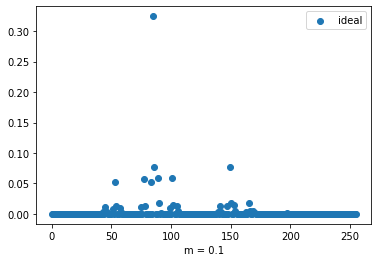

In [ ]:
import matplotlib.colors as mcolors
eigenvectors = torch.tensor(np.load('number_of_qubits_8.npy')).float()

my_way8 = torch.zeros(2**8, dtype = torch.double)
print(eigenvectors.shape)
x = torch.arange(2**8)
my_way8 = eigenvectors
fig, ax = plt.subplots()
ax.scatter(x, my_way8**2, alpha = 1, label='ideal')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()

In [ ]:
p = (my_way8**2 > 0.04).nonzero().reshape(-1)
print(basis[p])


tensor([[0., 0., 1., 1., 0., 1., 0., 1.],
        [0., 1., 0., 0., 1., 1., 0., 1.],
        [0., 1., 0., 1., 0., 0., 1., 1.],
        [0., 1., 0., 1., 0., 1., 0., 1.],
        [0., 1., 0., 1., 0., 1., 1., 0.],
        [0., 1., 0., 1., 1., 0., 0., 1.],
        [0., 1., 1., 0., 0., 1., 0., 1.],
        [1., 0., 0., 1., 0., 1., 0., 1.]])


torch.Size([64])


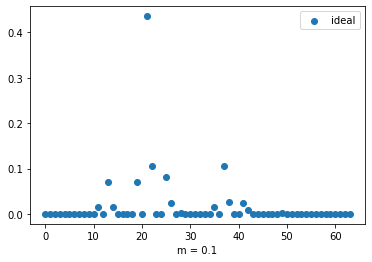

In [ ]:
import matplotlib.colors as mcolors
eigenvectors = torch.tensor(np.load('number_of_qubits_6.npy')).float()

my_way6 = torch.zeros(2**6, dtype = torch.double)
print(eigenvectors.shape)
x = torch.arange(2**6)
my_way6 = eigenvectors
fig, ax = plt.subplots()
ax.scatter(x, eigenvectors**2, alpha = 1, label='ideal')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()

tensor(0.8467)


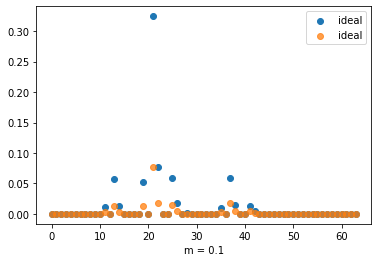

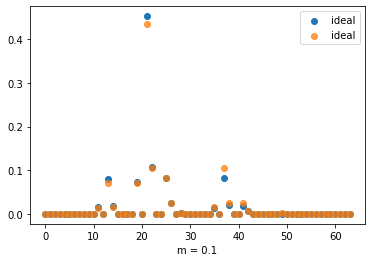

tensor([[0.0790],
        [0.0738],
        [0.4525],
        [0.1083],
        [0.0828],
        [0.0828]])


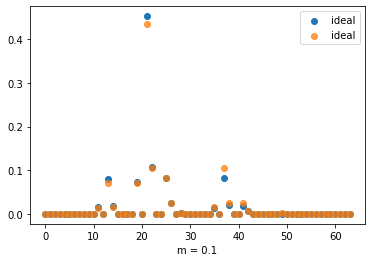

In [ ]:
r = my_way8[64:64+64]
print(r.norm())
x = torch.arange(2**6)
fig, ax = plt.subplots()
ax.scatter(x, r**2, alpha = 1, label='ideal')
ax.scatter(x, (my_way6*0.4216)**2, alpha = 0.75, label='ideal')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()
r = r/r.norm()
fig, ax = plt.subplots()
ax.scatter(x, r**2, alpha = 1, label='ideal')
ax.scatter(x, my_way6**2, alpha = 0.75, label='ideal')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()
p = (r**2 > 0.06).nonzero()
print(r[p]**2)
r=r/r.norm()
fig, ax = plt.subplots()
ax.scatter(x, r**2, alpha = 1, label='ideal')
ax.scatter(x, my_way6**2, alpha = 0.75, label='ideal')
ax.set_xlabel('m = 0.1')
ax.legend()
plt.show()